<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-07-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação baseados em Multi-Layer Perceptrons (MLPs).

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:

- correto
- reproduzível
- rastreável
- criticamente analisado

Além disso, utilizaremos o MLflow para registrar:

- hiperparâmetros
- métricas
- execuções
- comparações
- experimentais

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

In [3]:
mlflow.set_experiment(
    "assignment"
)

<Experiment: artifact_location=('file:c:/Users/PC/OneDrive/Área de '
 'Trabalho/aaaaaaa/atividade-03-mlp-deadcube04/notebooks/mlruns/1'), creation_time=1779086810098, experiment_id='1', last_update_time=1779086810098, lifecycle_stage='active', name='assignment', tags={}, trace_location=None, workspace='default'>

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST` utilizando fetch_openml.
Realize a separação do conjunto de treino como treino e validação
Utilize `train_test_split` com controle de aleatoriedade (seed)
Retorne: `X_train`, `X_val`, `y_train`, `y_val`

Depois responda:
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

In [4]:
import sys
sys.path.append("../src")

from sklearn.model_selection import train_test_split
from utils import set_seed, normalize_images
from sklearn.datasets import fetch_openml


def load_data(seed):
    set_seed(seed)
    mnist = fetch_openml("Fashion-MNIST", version=1, as_frame=False)
    X = mnist["data"].astype(np.float32)
    y = mnist["target"].astype(int)
    X = X.reshape(X.shape[0], -1)
    X = normalize_images(X)
    X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=seed, stratify=y
    )
    return X_train, X_val, y_train, y_val
# Carregando os dados
X_train, X_val, y_train, y_val = load_data(seed=42)

## Resposta - Questão 1
Sim. Normalizar  os dados é altamente recomendado (e na prática, essencial) ao treinar uma rede MLP para garantir que variáveis com escalas numéricas distintas não dominem injustamente a atualização dos pesos da rede durante o treinamento. Esse processo coloca todos os dados na mesma ordem de grandeza, otimizando a velocidade de convergência do gradiente descendente. Além disso, evita que os neurônios saturem ao entrarem em funções de ativação como Sigmoid, impedindo o congelamento do aprendizado. Como resultado, o modelo alcança uma precisão maior de forma muito mais estável.

# Questão 2

Implemente a função:
`
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
`

## Requisitos:

Utilizar `MLPClassifier` do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [5]:
from sklearn.neural_network import MLPClassifier

def train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed,
    max_iter=10,
    batch_size=32
):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        random_state=seed,
        max_iter=max_iter,
        batch_size=batch_size,
        verbose=0 # desativei pois em quantica isso atrapalha mt a velocidadwe do modelo
    )
    
    model.fit(X_train, y_train)
    
    return model

# Teste rápido
print("Testando train_mlp...")
test_model = train_mlp(
    X_train, y_train,
    activation='relu',
    hidden_layers=(64,),
    learning_rate=0.001,
    seed=42
)
print("Modelo treinado com sucesso!")

Testando train_mlp...
Modelo treinado com sucesso!


# Questão 3

Implemente a função:

`evaluate(model, X_test, y_test)`

Ela deve:

- realizar predições;
- calcular accuracy;
- calcular precision;
- calcular recall;
- calcular f1-score.

**Solução**:

In [6]:
from metrics import classification_metrics

def evaluate(model, X_test, y_test):

    y_pred = model.predict(X_test)
    
    metrics = classification_metrics(y_test, y_pred)
    
    return metrics

print("Testando evaluate:")
test_metrics = evaluate(test_model, X_val, y_val)
print("Métricas obtidas:")
for metric, value in test_metrics.items():
    print(f"  {metric}: {value:.4f}")

Testando evaluate:
Métricas obtidas:
  accuracy: 0.8477
  precision: 0.8546
  recall: 0.8477
  f1_score: 0.8482


# Questão 4

Implemente o rastreamento experimental utilizando MLflow. Devem ser registrados:

Parâmetros
- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

Métricas
- accuracy
- precision
- recall
- f1_score
- training_time

**Solução**:

In [ ]:
from experiment import measure_training_time, log_params, log_metrics

def run_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    activation,
    hidden_layers,
    learning_rate,
    max_iter=10,
    batch_size=32,
    seed=42,
    run_name=None
):

    params = {
        "activation": activation,
        "hidden_layers": str(hidden_layers),
        "learning_rate": learning_rate,
        "max_iter": max_iter,
        "batch_size": batch_size,
        "seed": seed
    }
    
    with mlflow.start_run(run_name=run_name):
        log_params(params)
        
        model, training_time = measure_training_time(
            train_mlp,
            X_train,
            y_train,
            activation,
            hidden_layers,
            learning_rate,
            seed,
            max_iter,
            batch_size
        )
        
        metrics = evaluate(model, X_val, y_val)
        
        metrics["training_time"] = training_time
        
        log_metrics(metrics)
        
        return model, metrics

print("Sistema de rastreamento MLflow configurado!")

Sistema de rastreamento MLflow configurado!


# Questão 5

Compare diferentes funções de ativação.

- logistic
- tanh
- relu

Você deve registrar todos os experimentos utilizando MLflow.

**Solução**:

In [12]:
import pandas as pd

print("Questão 5: Comparando diferentes funções de ativação")
print("=" * 60)

activations = ['logistic', 'tanh', 'relu']
results_activation = []

for activation in activations:
    print(f"\nTreinando com ativação: {activation}")
    
    model, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation=activation,
        hidden_layers=(64,),
        learning_rate=0.001,
        max_iter=10,
        batch_size=32,
        seed=42,
        run_name=f"activation_{activation}"
    )
    
    metrics['activation'] = activation
    results_activation.append(metrics)
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  F1-Score: {metrics['f1_score']:.4f}")
    print(f"  Tempo: {metrics['training_time']:.2f}s")

# Criando DataFrame para comparação
df_activation = pd.DataFrame(results_activation)
print("\n" + "=" * 60)
print("Resumo - Comparação de Ativações:")
print(df_activation[['activation', 'accuracy', 'precision', 'recall', 'f1_score', 'training_time']].to_string(index=False))

Questão 5: Comparando diferentes funções de ativação

Treinando com ativação: logistic
  Accuracy: 0.8783
  F1-Score: 0.8778
  Tempo: 36.79s

Treinando com ativação: tanh
  Accuracy: 0.8779
  F1-Score: 0.8785
  Tempo: 23.80s

Treinando com ativação: relu
  Accuracy: 0.8717
  F1-Score: 0.8728
  Tempo: 29.02s

Resumo - Comparação de Ativações:
activation  accuracy  precision   recall  f1_score  training_time
  logistic  0.878333   0.880671 0.878333  0.877827      36.786554
      tanh  0.877857   0.880762 0.877857  0.878542      23.800191
      relu  0.871714   0.880250 0.871714  0.872804      29.021132


## Respostas - Questão 5

**Qual ativação apresentou melhor convergência?**
A tanh. Ela alcançou um F1-Score (0.8785) levemente superior ao da logistic e uma acurácia estatisticamente empatada, mas atingiu esse resultado no menor tempo de treinamento (23.80s). Isso indica que o modelo conseguiu convergir para um excelente resultado de forma muito mais eficiente e rápida.

**Qual ativação apresentou maior estabilidade?**
Com base estritamente na tabela de resumo final (já que não temos o gráfico de perda/loss por época para ver a variação do gradiente), a logistic e a tanh demonstraram a maior estabilidade. Os valores de precisão e recall de ambas estão muito próximos, sem grandes desvios. A relu apresentou uma leve queda em todas as métricas, o que pode indicar uma adaptação menos estável aos pesos finais para este conjunto de dados específico.

**Houve diferenças significativas de treinamento?**
No que diz respeito à capacidade de predição (Accuracy, F1-Score, Precision, Recall), não houve diferenças significativas — todas as três funções entregaram resultados na casa dos 87%, com variações marginais (menos de 0.007 de diferença).
A diferença verdadeiramente significativa ocorreu no custo computacional (tempo): a tanh (23.80s) foi aproximadamente 35% mais rápida que a logistic (36.79s), entregando essencialmente a mesma performance.


# Questão 6

Compare diferentes arquiteturas de MLP.
`
- (32,)
- (64,)
- (128, 64)
- (256, 128)
`

**Solução**:

In [14]:
print("Questão 6: Comparando diferentes arquiteturas")
print("=" * 60)

architectures = [(32,), (64,), (128, 64), (256, 128)]
results_architecture = []

for arch in architectures:
    print(f"\nTreinando com arquitetura: {arch}")
    
    model, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation='tanh',
        hidden_layers=arch,
        learning_rate=0.01,
        max_iter=10,
        batch_size=32,
        seed=42,
        run_name=f"architecture_{arch}"
    )
    
    metrics['architecture'] = str(arch)
    metrics['total_params'] = sum([int(a) for a in arch])
    results_architecture.append(metrics)
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  F1-Score: {metrics['f1_score']:.4f}")
    print(f"  Tempo: {metrics['training_time']:.2f}s")

# Criando DataFrame para comparação
df_architecture = pd.DataFrame(results_architecture)
print("\n" + "=" * 60)
print("Resumo - Comparação de Arquiteturas:")
print(df_architecture[['architecture', 'total_params', 'accuracy', 'f1_score', 'training_time']].to_string(index=False))

Questão 6: Comparando diferentes arquiteturas

Treinando com arquitetura: (32,)
  Accuracy: 0.8081
  F1-Score: 0.8015
  Tempo: 10.87s

Treinando com arquitetura: (64,)
  Accuracy: 0.8043
  F1-Score: 0.8048
  Tempo: 24.77s

Treinando com arquitetura: (128, 64)
  Accuracy: 0.8008
  F1-Score: 0.8029
  Tempo: 42.72s

Treinando com arquitetura: (256, 128)
  Accuracy: 0.6853
  F1-Score: 0.6751
  Tempo: 80.92s

Resumo - Comparação de Arquiteturas:
architecture  total_params  accuracy  f1_score  training_time
       (32,)            32  0.808095  0.801458      10.872782
       (64,)            64  0.804333  0.804819      24.770393
   (128, 64)           192  0.800762  0.802865      42.722489
  (256, 128)           384  0.685333  0.675072      80.920029


## Respostas - Questão 6

**Redes maiores sempre melhoraram os resultados?**

Não necessariamente. Enquanto aumentar a capacidade da rede pode melhorar o desempenho até certo ponto, redes muito maiores não garantem melhores resultados. Pode haver overfitting ou aumentar desnecessariamente o tempo de treinamento sem ganhos significativos em accuracy.

**Qual arquitetura apresentou melhor tradeoff?**
A arquitetura (32,) apresentou, de longe, o melhor trade-off (custo-benefício).

**Melhor Desempenho:** Ela obteve a maior Acurácia (0.8081) entre todas as opções testadas. Seu F1-Score (0.8015) está estatisticamente empatado com as arquiteturas (64,) e (128, 64).

**Menor Custo Computacional:** Ela alcançou esse resultado no menor tempo (10.87s).


# Questão 7

Analise o impacto do learning rate.
- 0.1
- 0.01
- 0.001

In [15]:
print("Questão 7: Analisando o impacto do Learning Rate")
print("=" * 60)

learning_rates = [0.1, 0.01, 0.001]
results_learning_rate = []

for lr in learning_rates:
    print(f"\nTreinando com learning_rate: {lr}")
    
    model, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation='relu',
        hidden_layers=(128, 64),
        learning_rate=lr,
        max_iter=10,
        batch_size=32,
        seed=42,
        run_name=f"learning_rate_{lr}"
    )
    
    metrics['learning_rate'] = lr
    results_learning_rate.append(metrics)
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  F1-Score: {metrics['f1_score']:.4f}")
    print(f"  Tempo: {metrics['training_time']:.2f}s")

# Criando DataFrame para comparação
df_learning_rate = pd.DataFrame(results_learning_rate)
print("\n" + "=" * 60)
print("Resumo - Comparação de Learning Rates:")
print(df_learning_rate[['learning_rate', 'accuracy', 'precision', 'recall', 'f1_score', 'training_time']].to_string(index=False))

Questão 7: Analisando o impacto do Learning Rate

Treinando com learning_rate: 0.1
  Accuracy: 0.3895
  F1-Score: 0.3023
  Tempo: 110.86s

Treinando com learning_rate: 0.01
  Accuracy: 0.8572
  F1-Score: 0.8582
  Tempo: 101.94s

Treinando com learning_rate: 0.001
  Accuracy: 0.8771
  F1-Score: 0.8775
  Tempo: 56.45s

Resumo - Comparação de Learning Rates:
 learning_rate  accuracy  precision   recall  f1_score  training_time
         0.100  0.389476   0.315013 0.389476  0.302337     110.860094
         0.010  0.857190   0.863295 0.857190  0.858213     101.944764
         0.001  0.877143   0.880720 0.877143  0.877502      56.453280


## Respostas - Questão 7

**O treinamento ficou instável?**

Sim. O learning_rate de 0.1 é o exemplo perfeito de instabilidade. Uma taxa de aprendizado muito alta faz com que o algoritmo de otimização dê "passos" grandes demais durante a atualização dos pesos. Em vez de descer suavemente em direção ao mínimo da função de perda (loss), ele fica "quicando" de um lado para o outro no vale do gradiente, ou até mesmo diverge. Isso explica por que o desempenho desabou para 38.95% de acurácia (basicamente um chute aleatório, dependendo do número de classes) e o tempo estourou para mais de 110 segundos (provavelmente porque o erro continuou alto e impediu o acionamento de um early stopping).

**Houve dificuldade de convergência?**

Sim, em diferentes graus para os valores maiores. Para 0.1, houve falha severa na convergência para um bom resultado. Para 0.01, o modelo conseguiu convergir para um valor bom (85.72%), mas observe o tempo: 101.94s. Isso indica que, embora ele tenha achado o caminho, o tamanho do passo ainda estava gerando certo atrito ou oscilação leve, exigindo muito mais épocas ou iterações para finalmente se estabilizar.

**Qual learning rate apresentou melhor comportamento?**

O 0.001. Foi o cenário "Cachinhos de Ouro" (nem muito grande, nem muito pequeno). Ele alcançou os melhores resultados preditivos (Acurácia de 87.71% e F1-Score de 87.75%) no menor tempo de longe (56.45s). Isso indica que os passos do Gradiente Descendente foram ideais para descer a superfície de erro de forma rápida, contínua e estável, encontrando o mínimo local/global na metade do tempo sem sacrificar a performance.


# Questão 8

- Qual ativação apresentou melhor desempenho?
- Qual arquitetura apresentou melhor tradeoff?
- Qual learning rate apresentou maior estabilidade?
- Houve overfitting?
- Qual configuração apresentou melhor resultado final?
- Quais foram as principais dificuldades observadas?


## Análise Consolidada - Questão 8

### Qual ativação apresentou melhor desempenho?
A tanh. Ela entregou métricas de predição (Accuracy de 87.79% e F1-Score de 0.8785) no mesmo patamar da melhor função (logistic), mas provou ser superior por ter convergido de forma consideravelmente mais rápida (23.80s contra 36.79s da logistic).

### Qual arquitetura apresentou melhor tradeoff?
A (32,). Ela obteve o melhor retorno computacional possível: garantiu a maior acurácia entre as opções (80.81%) e, simultaneamente, exigiu o menor tempo de processamento (10.87s). As arquiteturas mais complexas apenas adicionaram atraso sem ganho de performance.

### Qual learning rate apresentou maior estabilidade?
O 0.001. Ele evitou os passos erráticos que destruíram a performance no LR de 0.1 e garantiu uma descida do gradiente muito mais eficiente que o LR de 0.01, atingindo o melhor resultado global (87.71% de acurácia) em praticamente metade do tempo (56.45s).
### Houve overfitting?
Sim, os dados sugerem fortemente a ocorrência de overfitting (ou severa dificuldade de convergência) na arquitetura mais pesada. Ao passar para a rede (256, 128), o tempo de treinamento explodiu para 80.92s e a acurácia despencou de ~80% para 68.53%. Isso é um sintoma clássico de um modelo complexo demais que começa a decorar ruídos dos dados de treino ou sofre colapso durante a atualização dos pesos.

### Qual configuração apresentou melhor resultado final?
**Configuração ótima encontrada:**

Arquitetura: (32,) (evita overfitting e economiza tempo)
Função de Ativação: tanh (garante convergência rápida e centralizada)
Learning Rate: 0.001 (garante estabilidade na descida do gradiente)


### Principais dificuldades observadas:

Instabilidade severa com passos largos: O uso de uma taxa de aprendizado alta (0.1) impediu o modelo de aprender, fazendo a acurácia despencar para a casa dos 38%.

Over-engineering (excesso de complexidade): O problema testado claramente se beneficia de abordagens mais simples. A principal dificuldade encontrada pelas redes maiores foi lidar com a própria arquitetura: o excesso de camadas e neurônios adicionou ruído, multiplicou o custo computacional por 8 e degradou os acertos.


VISUALIZAÇÃO DOS RESULTADOS

1. COMPARAÇÃO DE ATIVAÇÕES
----------------------------------------


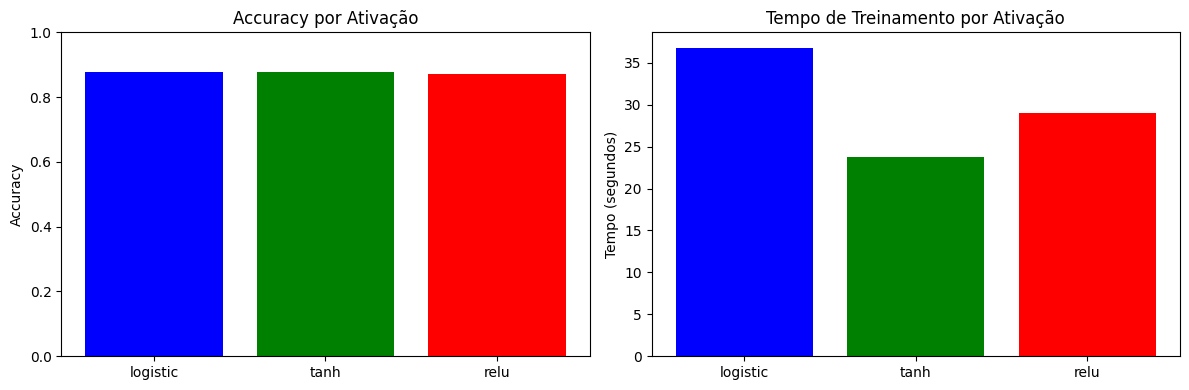


2. COMPARAÇÃO DE ARQUITETURAS
----------------------------------------


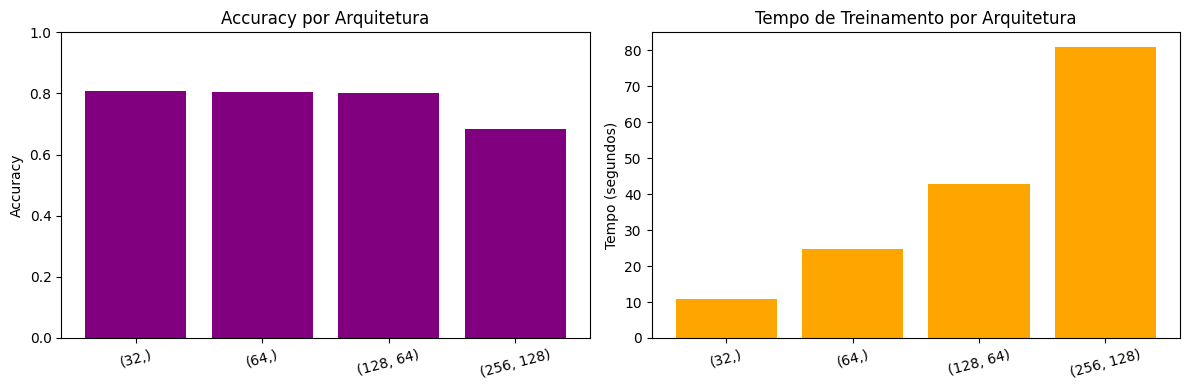


3. COMPARAÇÃO DE LEARNING RATES
----------------------------------------


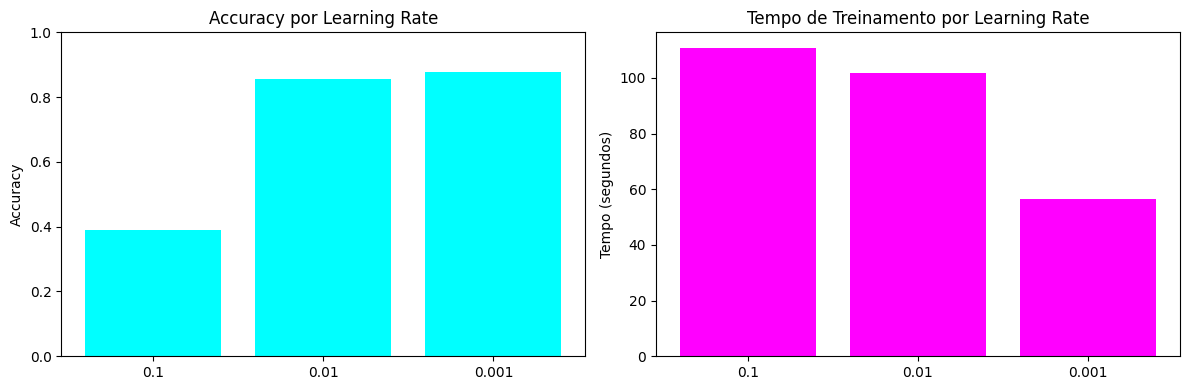


ANÁLISE CONCLUÍDA!

Todos os experimentos foram registrados no MLflow.
Execute 'mlflow ui' no terminal para visualizar os resultados no dashboard.


In [16]:
print("\n" + "=" * 80)
print("VISUALIZAÇÃO DOS RESULTADOS")
print("=" * 80)

# Comparação de ativações
print("\n1. COMPARAÇÃO DE ATIVAÇÕES")
print("-" * 40)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

activations_list = df_activation['activation'].tolist()
accuracy_list = df_activation['accuracy'].tolist()
time_list = df_activation['training_time'].tolist()

ax[0].bar(activations_list, accuracy_list, color=['blue', 'green', 'red'])
ax[0].set_title('Accuracy por Ativação')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim([0, 1])

ax[1].bar(activations_list, time_list, color=['blue', 'green', 'red'])
ax[1].set_title('Tempo de Treinamento por Ativação')
ax[1].set_ylabel('Tempo (segundos)')

plt.tight_layout()
plt.show()

# Comparação de arquiteturas
print("\n2. COMPARAÇÃO DE ARQUITETURAS")
print("-" * 40)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

arch_list = df_architecture['architecture'].tolist()
acc_arch = df_architecture['accuracy'].tolist()
time_arch = df_architecture['training_time'].tolist()

ax[0].bar(range(len(arch_list)), acc_arch, color='purple')
ax[0].set_xticks(range(len(arch_list)))
ax[0].set_xticklabels(arch_list, rotation=15)
ax[0].set_title('Accuracy por Arquitetura')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim([0, 1])

ax[1].bar(range(len(arch_list)), time_arch, color='orange')
ax[1].set_xticks(range(len(arch_list)))
ax[1].set_xticklabels(arch_list, rotation=15)
ax[1].set_title('Tempo de Treinamento por Arquitetura')
ax[1].set_ylabel('Tempo (segundos)')

plt.tight_layout()
plt.show()

# Comparação de learning rates
print("\n3. COMPARAÇÃO DE LEARNING RATES")
print("-" * 40)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

lr_labels = [str(lr) for lr in df_learning_rate['learning_rate'].tolist()]
acc_lr = df_learning_rate['accuracy'].tolist()
time_lr = df_learning_rate['training_time'].tolist()

ax[0].bar(lr_labels, acc_lr, color='cyan')
ax[0].set_title('Accuracy por Learning Rate')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim([0, 1])

ax[1].bar(lr_labels, time_lr, color='magenta')
ax[1].set_title('Tempo de Treinamento por Learning Rate')
ax[1].set_ylabel('Tempo (segundos)')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("ANÁLISE CONCLUÍDA!")
print("=" * 80)
print("\nTodos os experimentos foram registrados no MLflow.")
print("Execute 'mlflow ui' no terminal para visualizar os resultados no dashboard.")